In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import tensorflow.keras.layers as tfl

os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [2]:
tf.random.set_seed(42)

In [3]:
#0. Load Data
data = pd.read_csv(r"data\FR_LMP_Forecasts\FR_lmp_processed.csv")
data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66
...,...,...,...,...,...,...,...
52598,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18
52599,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23
52600,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00
52601,2025-09-30 23:00:00+02:00,2025,9,30,23,+02:00,75.73


In [4]:
# 1. Train/Dev/Test Split
#Train : 2022-07 to 2024-12-31
#Dev : 2025-01 to 2025-06-30
#Test : 2025-07 to 2025-09-30
def split_data(data):
    df = data.copy()
    # Create a date column from Year, Month, Day (ignore Hour for date-based splitting)
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    # Filter by date ranges
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test
train, dev, test = split_data(data)
print(f"number of training samples: {len(train)}")
print(f"number of validation samples: {len(dev)}")
print(f"number of test samples: {len(test)}")

#Save the datasets
train.to_csv(r"data\Processed_Data\FR\train.csv", index=False)
dev.to_csv(r"data\Processed_Data\FR\dev.csv", index=False)
test.to_csv(r"data\Processed_Data\FR\test.csv", index=False)

number of training samples: 35060
number of validation samples: 8783
number of test samples: 8759


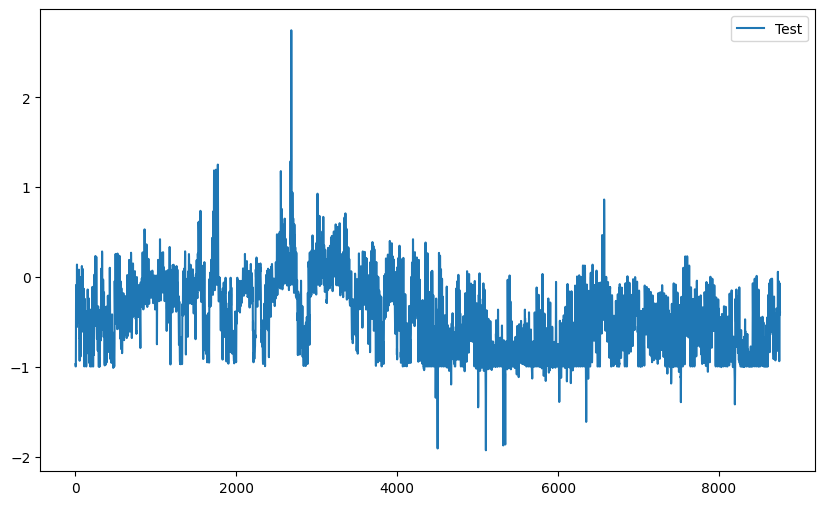

In [5]:
#Normalize the datasets
mean=train['EUR/MWh'].mean()
std=train['EUR/MWh'].std()
train['EUR/MWh']=(train['EUR/MWh']-mean)/std
dev['EUR/MWh']=(dev['EUR/MWh']-mean)/std
test['EUR/MWh']=(test['EUR/MWh']-mean)/std

plt.figure(figsize=(10,6))
plt.plot(test['EUR/MWh'], label='Test')
plt.legend()
plt.show()


In [6]:
def create_sliding_window(data, window_size, forecast_horizon=24):
    """
    Create sliding windows for input features (X) and target values (y).

    Arguments:
    data -- DataFrame containing the time series data
    window_size -- Number of past time steps to use as input
    forecast_horizon -- Number of future time steps to predict (default: 24 for day-ahead)

    Returns:
    X -- Input features, shape (num_samples, window_size)
    y -- Target values, shape (num_samples, forecast_horizon)
    """
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data['EUR/MWh'].iloc[i:i + window_size].values)
        y.append(data['EUR/MWh'].iloc[i + window_size:i + window_size + forecast_horizon].values)
    return np.array(X), np.array(y)


In [7]:

def build_model(input_shape, layer_dims, output_dim, l1_lambda, dropout, lr, leaky_alpha, clipnorm=None, use_batchnorm=False):
    regularizer = tf.keras.regularizers.l1(l1_lambda) if l1_lambda and l1_lambda > 0 else None
    initializer = tf.keras.initializers.HeNormal()

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))

    for dim in layer_dims:
        model.add(tf.keras.layers.Dense(dim,
                                        kernel_initializer=initializer,
                                        kernel_regularizer=regularizer))
        if use_batchnorm:
            model.add(tf.keras.layers.BatchNormalization(momentum=0.99, epsilon=1e-3))
        # activation after BatchNorm
        model.add(tf.keras.layers.LeakyReLU(alpha=leaky_alpha))
        if dropout and dropout > 0:
            # Dropout typically goes after activation
            model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(output_dim, kernel_initializer=initializer))  # linear outputs

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm) if clipnorm else tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mae', metrics=['mae'])
    return model


In [8]:

# 3. Train the Model
def train_model(model, X_train, y_train, X_dev, y_dev, batch_size,epochs):
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        batch_size=batch_size,
        epochs=epochs,
        verbose=True
    )
    return history


In [9]:
# Build X_train, y_train, X_dev, y_dev
t = 366  # Input window size (14 days)
forecast_horizon = 24  # Predict the next 24 hours
X_train, y_train = create_sliding_window(train, t, forecast_horizon)
X_dev, y_dev = create_sliding_window(dev, t, forecast_horizon)


In [12]:

# Build and train the model
layer_dims = [256, 128]  #[2048,1024,512,256,128]
model = build_model(input_shape=(t,), layer_dims=layer_dims, output_dim=forecast_horizon, l1_lambda=0.2,dropout=0.1, lr=1e-3, leaky_alpha=0.1)
history = train_model(model, X_train, y_train, X_dev, y_dev, batch_size=128, epochs=50)


Epoch 1/50


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 293.9266 - mae: 0.5974 - val_loss: 3.1631 - val_mae: 0.2993
Epoch 2/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.5212 - mae: 0.6798 - val_loss: 3.1311 - val_mae: 0.2976
Epoch 3/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.4999 - mae: 0.6796 - val_loss: 3.1060 - val_mae: 0.2996
Epoch 4/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.4902 - mae: 0.6795 - val_loss: 3.1156 - val_mae: 0.2995
Epoch 5/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.4842 - mae: 0.6797 - val_loss: 3.1035 - val_mae: 0.2997
Epoch 6/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.4784 - mae: 0.6794 - val_loss: 3.0899 - val_mae: 0.2993
Epoch 7/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.4745 - mae: 0.6795 - val_loss: 3.0847 - val_mae: 0.2988
Epoch 8/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.4711 - mae: 0.6792 - val_loss: 3.0854 - val_mae: 0.2982
Epoch 9/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.470

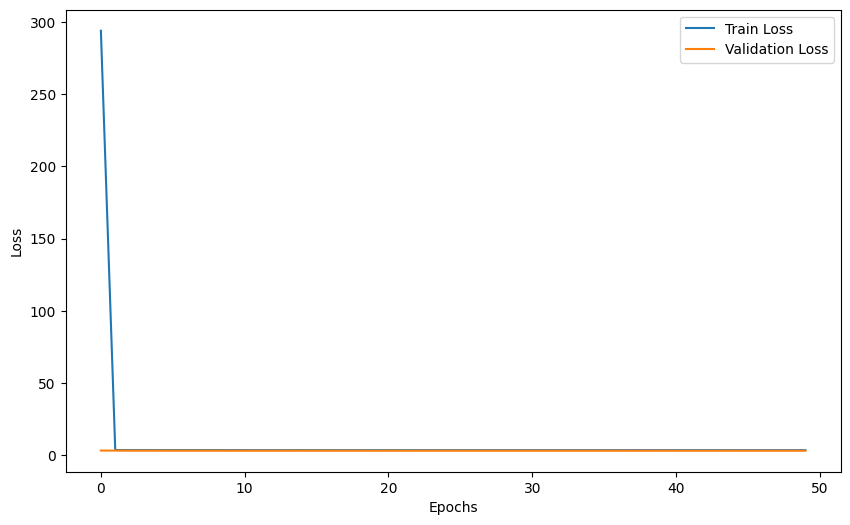

In [13]:

# Plot training history
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()



In [14]:

def evaluate_model(model, X, y, shift=24*7, predict_batch_size=128):
    """
    Evaluate the model and compute MAE and relative MAE against a 7-day naive baseline.
    Assumes samples are hourly and consecutive so `shift` samples = shift hours.
    """
    # predictions (dropout disabled by Keras during predict)
    predictions = model.predict(X, batch_size=predict_batch_size)

    if len(y) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")

    # build naive baseline: no wrapping, first `shift` rows invalid
    naive_baseline = np.empty_like(y, dtype=float)
    naive_baseline[:shift, :] = np.nan
    naive_baseline[shift:, :] = y[:-shift, :]

    # drop the invalid prefix so arrays align
    preds = predictions[shift:]
    true = y[shift:]
    naive = naive_baseline[shift:]

    # compute MAEs
    mae_model = np.mean(np.abs(preds - true))
    mae_naive = np.mean(np.abs(naive - true))

    if mae_naive == 0:
        rmae = np.inf
        accuracy = -np.inf
    else:
        rmae = mae_model / mae_naive
        accuracy = 1.0 - rmae

    print(f"MAE model: {mae_model:.6f}, MAE naive: {mae_naive:.6f}")
    print(f"Relative MAE (rMAE): {rmae:.4f}")
    print(f"Accuracy (1 - rMAE): {accuracy:.4f}")

    return {
        "predictions": preds,
        "mae_model": mae_model,
        "mae_naive": mae_naive,
        "rmae": rmae,
        "accuracy": accuracy
    }
# ...existing code...

In [15]:

# Evaluate the model
predictions_dev = evaluate_model(model, X_train, y_train)
print(f"rMAE: {predictions_dev['rmae']}")


271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE model: 0.680899, MAE naive: 0.260297
Relative MAE (rMAE): 2.6159
Accuracy (1 - rMAE): -1.6159
rMAE: 2.61585591496594


In [ ]:
#Plot a few predictions vs true values
plt.figure(figsize=(12,6))
num_plots = 3
for i in range(num_plots):
    plt.subplot(num_plots, 1, i + 1)
    plt.plot(predictions_dev['predictions'][i], label='Predicted', marker='o')
    plt.plot(y_train[24*7 + i], label='True', marker='x')
    plt.title(f'Sample {i+1}')
    plt.xlabel('Hour')
    plt.ylabel('Normalized EUR/MWh')
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

import math

# callbacks to avoid long useless runs
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
ckpt = tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

def quick_experiment(layer_dims=None, l2_lambda=1e-4, dropout=0.2, lr=1e-4, leaky_alpha=0.01,
                     use_batchnorm=True, epochs=10, subset_frac=0.25, batch_size=128):
    """
    Run a fast experiment on a subset for quick signal.
    """
    if layer_dims is None:
        layer_dims = [512, 256, 128]  # smaller than your full net
    model = build_model(input_shape=(t,), layer_dims=layer_dims, output_dim=forecast_horizon,
                        l2_lambda=l2_lambda, dropout=dropout, lr=lr, leaky_alpha=leaky_alpha,
                        clipnorm=None, use_batchnorm=use_batchnorm)
    # use a fraction of training data to iterate fast
    n = max(100, int(len(X_train) * subset_frac))
    history = model.fit(X_train[:n], y_train[:n],
                        validation_data=(X_dev, y_dev),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early, reduce_lr, ckpt],
                        verbose=2)
    return model, history

# example quick tries
model_small, h1 = quick_experiment(layer_dims= [2048, 1024, 512, 256, 128], l2_lambda=1e-2, dropout=0.2, lr=1e-3, epochs=10)
model_smaller, h2 = quick_experiment(layer_dims=[2048, 1024, 512, 256, 128], l2_lambda=1e-3, dropout=0.3, lr=5e-4, epochs=10)


In [ ]:

def plot_losses(*histories, labels=None):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,6))
    for i, h in enumerate(histories):
        if h is None:
            continue
        label = labels[i] if labels and i < len(labels) else f'Run {i+1}'
        if 'loss' in h.history:
            plt.plot(h.history['loss'], label=f'{label} Train Loss')
        if 'val_loss' in h.history:
            plt.plot(h.history['val_loss'], label=f'{label} Val Loss', linestyle='--')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MAE)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Example usage: adjust to the history variables you have
plot_losses(h1, h2, labels=['Model Small', 'Model Smaller'])

In [ ]:
predictions_1= evaluate_model(model_small, X_dev, y_dev)
predictions_2= evaluate_model(model_smaller, X_dev, y_dev)